# understanding the data

#### torchvision

#### PyTorch’s computer vision package.

#### Contains:

#### datasets
#### pretrained models
#### transforms

In [187]:
import torch
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torchvision import transforms

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])


#### ToTensor()

Very important.

Images normally come as:

PIL images
pixel arrays

Deep learning models need:

tensors

So this converts image → tensor.

# NOW LOAD DATASET

In [188]:
train_data=datasets.CIFAR10(
  root="data",
  train=True,
  download=True,
  transform=ToTensor()
)

test_data=datasets.CIFAR10(
  root="data",
  train=False,
  download=True,
  transform=ToTensor()
)

# root="data"

# Dataset will be stored inside:

# ./data

# folder.

# -----------------------------------------------

# train=True--> Load training split.
# CIFAR10 already comes divided into:
# train data
# test data

#--------------------------------------------------
# download=True
# If dataset absent:
# automatically download it.

#-------------------------------------------------------

# transform=ToTensor()
# This is VERY important.
# Without this:
# image stays PIL format
# With this:
# image becomes PyTorch tensor
#---------------------------------------------------------

# CIFAR10 Image Shape

# Each image:
# 32 × 32 pixels
# with:
# Red channel
# Green channel
# Blue channel
# So internally:
# 3 × 32 × 32
#------------------------------------------------------------

# Why Deep Learning Uses Channels
# Because CNN filters operate across channels.
# For RGB:
# 3 channels
# For grayscale:
# 1 channel


c:\Users\ahlaw\OneDrive\Desktop\PYTORCH\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [189]:
len(train_data), len(test_data)

(50000, 10000)

# NOW Let's Inspect ONE Image Properly

In [190]:
image,label=train_data[0]
print(type(image))
print(image.shape)
print(label)
print(image)
# image

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6
tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         

# WHY Tensor Values Become Decimal

### Original images have pixel values:

0 → 255

ToTensor() automatically normalizes them into:

0 → 1

This helps neural network training.

In [191]:
image.min(), image.max()

(tensor(0.), tensor(1.))

# NOW Let's VISUALIZE Properly

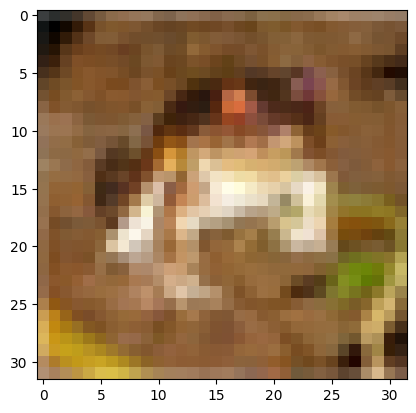

In [192]:
import matplotlib.pyplot as plt
plt.imshow(image.permute(1,2,0))
plt.show()

In [155]:
print(image.shape)
print(image.permute(1,2,0).shape)

torch.Size([3, 32, 32])
torch.Size([32, 32, 3])


# BATCHING
### USE OF DATALOADERS

#### Suppose we trained like this:

1 image
→ forward pass
→ backward pass
→ update

for all 50,000 images.

This would be:

very slow
unstable
inefficient for GPU

So We Use MINI-BATCHES

Instead of:

1 image at a time

we do:

32 images together

or:

64
128
etc.

# Create DataLoader

In [193]:
from torch.utils.data import DataLoader

BATCH_SIZE=32

train_dataloader=DataLoader(
  train_data,
  batch_size=BATCH_SIZE, # give me 32 images at once so that faster GPU usage
  shuffle=True
)

test_dataloader=DataLoader(
  test_data,
  batch_size=BATCH_SIZE,
  shuffle=False
)

## NOW Let's SEE Actual Batch Shapes

In [194]:
train_features_batch , train_labels_batch=next(iter(train_dataloader))
print(train_features_batch.shape)
print(train_labels_batch.shape)


# --------------------------------------------------------------------

# BEFORE Running — Predict Mentally
# Each image shape:
# (3,32,32)
# Batch size:
# 32
# So full batch should become:
# (32,3,32,32)
# Meaning:
# (batch_size, channels, height, width)

#--------------------------------------------------------------------------

# This Is EXACTLY What CNNs Expect
# Conv2D layers take input:
# (batch, channels, height, width)
#---------------------------------------------------------------------

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [195]:
print(train_features_batch[0].shape)

torch.Size([3, 32, 32])


# NOW Let's Observe One Batch Properly

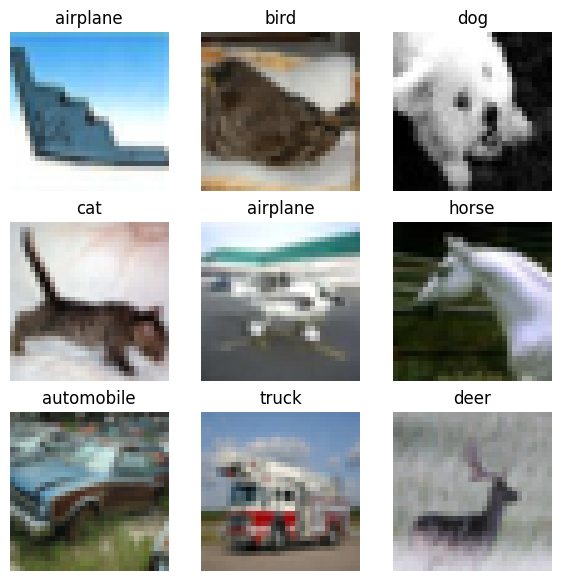

In [196]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))

for i in range(9) : 
  plt.subplot(3,3,i+1)
  image=train_features_batch[i]
  label=train_labels_batch[i]
  plt.imshow(image.permute(1,2,0))
  plt.title(train_data.classes[label])
  plt.axis(False)
plt.show()

# Understanding Conv2D

Why Normal Neural Networks Are Bad For Images

Suppose image:

32 × 32 × 3

Flattening gives:

3072 values

A normal linear layer:

nn.Linear(3072,1000)

creates HUGE parameters.

Also:

loses spatial structure
nearby pixels relationship disappears


# NOW Let's Build FIRST Conv Layer

In [197]:
from torch import nn

conv_layer=nn.Conv2d(
  in_channels=3,
  out_channels=32,
  kernel_size=3,
  stride=1,
  padding=1
)


#-------------------------------------------------------------------------

# IMPORTANT FORMULA

# Output size:
# (W−F+2P)/S + 1
# where:
# W=input size
# F=filter size
# P=padding
# S=stride
#----------------------------------------------------------------------------

# NOW Apply Conv Layer

In [198]:
output=conv_layer(train_features_batch)
print(train_features_batch.shape)
print(output.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32, 32, 32, 32])


# Let's VISUALIZE Feature Maps

In [199]:
import matplotlib.pyplot as plt
feature_map=output[0]
print(feature_map.shape)

# -------------------------------------------------------------------

# These are NOT RGB channels anymore.
# These are:
# learned feature channels
# Each one detects something different.

#------------------------------------------------------------------------

torch.Size([32, 32, 32])


# NOW Visualize First Few Feature Maps

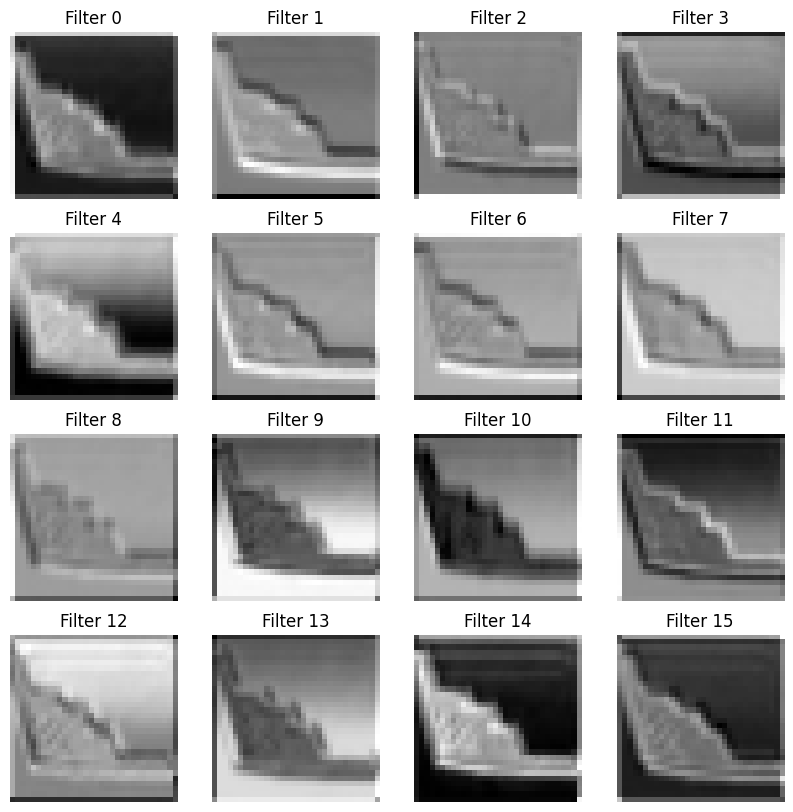

In [200]:
fig,axes=plt.subplots(4,4,figsize=(10,10))

for i,ax in enumerate(axes.flat):
  ax.imshow(feature_map[i].detach(),cmap="gray")
  ax.axis(False)
  ax.set_title(f"Filter {i}")
plt.show()

# --------------------------------------------------------------------------

# Important Deep Learning Intuition
# Early layers learn:
# edges
# colors
# corners
# Middle layers learn:
# textures
# shapes
# Deep layers learn:
# semantic structures
# ResNet/EfficientNet are just much deeper versions of this same idea.

#------------------------------------------------------------------------------

# MAXPOOLING

Why Pooling Exists

After convolution:

(32,32,32,32)

This is large.

Deep networks would become:

computationally expensive
memory heavy

Also:

small pixel shifts should not matter much

Example:

cat slightly left/right is still cat


### Pooling Goal
reduce spatial size
while preserving important features


# NOW Create Pool Layer

In [201]:
max_pool=nn.MaxPool2d(
  kernel_size=2
)

# NOW Apply Pooling

In [202]:
pooled_output=max_pool(output)
print(output.shape)
print(pooled_output.shape)

# --------------------------------------------------------------------

# VERY Important Insight
# Pooling changes:
# height/width
# NOT:
# channels
# because pooling acts spatially.

#----------------------------------------------------------------------------


torch.Size([32, 32, 32, 32])
torch.Size([32, 32, 16, 16])


# NOW Visualize Difference

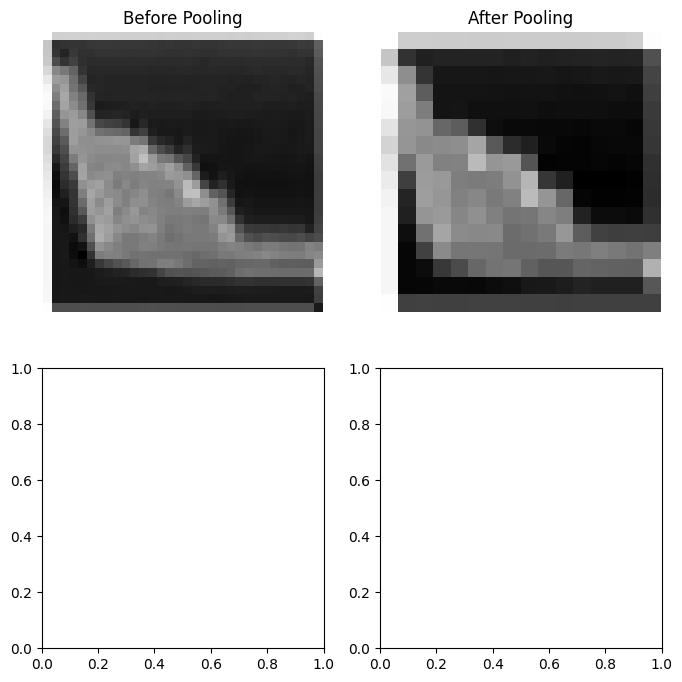

In [203]:
fig, axes = plt.subplots(2,2, figsize=(8,8))

axes[0,0].imshow(output[0][0].detach(), cmap="gray")
axes[0,0].set_title("Before Pooling")

axes[0,1].imshow(pooled_output[0][0].detach(), cmap="gray")
axes[0,1].set_title("After Pooling")

axes[0,0].axis(False)
axes[0,1].axis(False)

plt.show()

# -------------------------------------------------

# Observe Carefully
# After pooling:
# image becomes smaller
# important activations remain
# fine detail reduced

#------------------------------------------------

# VERY IMPORTANT

We are gradually:

increasing channels
reducing spatial dimensions

This is the core CNN philosophy.

# WHY Increase Channels?

More channels means:

more learned features

Early:

simple edges

Later:

complex patterns

## NOW Create First CNN Block

In [204]:
conv_block_1=nn.Sequential(
  nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1
  ),
  nn.ReLU(),
  
  nn.MaxPool2d(kernel_size=2)
)

# VERY Important Concept

# nn.Sequential means:

# run layers one after another

# NOW Pass Batch Through Block

In [205]:
block_output=conv_block_1(train_features_batch)
print(train_features_batch.shape)
print(block_output.shape)

print(block_output[0].shape)

torch.Size([32, 3, 32, 32])
torch.Size([32, 32, 16, 16])
torch.Size([32, 16, 16])


# Full CNN Architecture

In [206]:
class CIFAR10Model(nn.Module) : 
  def __init__(self):
    super().__init__()
    self.conv_block_1=nn.Sequential(
      nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.conv_block_2=nn.Sequential(
      nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.classifier=nn.Sequential(
      nn.Flatten(),
      nn.Linear(
        in_features=64*8*8,
        out_features=10
      )
    )
    
  def forward(self,x):
    x=self.conv_block_1(x);
    # print("After block 1:",x.shape)
    
    x=self.conv_block_2(x)
    # print("After block 2:", x.shape)
    
    x=self.classifier(x)
    
    # print("After classifier:", x.shape)
    
    return x
  
  
#   # -------------------------------------------------------------------
  
# #   MOST Important Step — Flatten
# # CNN output is still 4D tensor.
# # Linear layer expects:
# # (batch_size, features)
# # So flatten converts:
# # (32,64,8,8)
# # into:
# # (32,4096)
# # because:
# # 64×8×8=4096
# #---------------------------------------------------------------------------

# # Then Linear Layer
# # 4096 → 10
# # Why 10?
# # Because CIFAR10 has:
# # 10 classes

# #--------------------------------------------------------------------------

# # Final output shape:
# # (32,10)
# # Meaning:
# # 32 images
# # 10 logits per image

# # These are NOT probabilities yet.
# # They are:
# # raw logits
# # CrossEntropyLoss internally applies softmax.

# #--------------------------------------------------------------------------


# class CIFAR10Model(nn.Module):

#     def __init__(self):

#         super().__init__()

#         self.conv_block_1 = nn.Sequential(

#             nn.Conv2d(
#                 in_channels=3,
#                 out_channels=32,
#                 kernel_size=3,
#                 padding=1
#             ),

#             nn.ReLU(),

#             nn.Conv2d(
#                 in_channels=32,
#                 out_channels=32,
#                 kernel_size=3,
#                 padding=1
#             ),

#             nn.ReLU(),

#             nn.MaxPool2d(kernel_size=2)

#         )

#         self.conv_block_2 = nn.Sequential(

#             nn.Conv2d(
#                 in_channels=32,
#                 out_channels=64,
#                 kernel_size=3,
#                 padding=1
#             ),

#             nn.ReLU(),

#             nn.Conv2d(
#                 in_channels=64,
#                 out_channels=64,
#                 kernel_size=3,
#                 padding=1
#             ),

#             nn.ReLU(),

#             nn.MaxPool2d(kernel_size=2)

#         )

#         self.classifier = nn.Sequential(

#             nn.Flatten(),

#             nn.Linear(
#                 in_features=64*8*8,
#                 out_features=10
#             )

#         )

#     def forward(self, x):

#         x = self.conv_block_1(x)

#         x = self.conv_block_2(x)

#         x = self.classifier(x)

#         return x

# NOW Create Model

In [207]:
model=CIFAR10Model()
# train_features_batch

# NOW Pass One Batch

In [208]:
output=model(train_features_batch)
print(output.shape)

# --------------------------------------------------------------------------

# The only remaining pieces are:
# loss function
# optimizer
# training loop
# which you already learned earlier.

#-----------------------------------------------------------------------------

torch.Size([32, 10])


# Device Setup

In [209]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Move Model To GPU

In [210]:
model=CIFAR10Model().to(device)

# -------------------------------------------------------------------

# This moves:
# weights
# parameters
# computations
# to GPU memory.

#-------------------------------------------------------------------------

# IMPORTANT RULE
# If model on GPU:
# data must ALSO go to GPU
# Otherwise:
# device mismatch error occurs.

#-------------------------------------------------------------------------

# Loss Function

In [211]:
loss_fn=nn.CrossEntropyLoss()

# WHY CrossEntropyLoss?

# Because:

# multiclass classification
# 10 CIFAR classes

# -----------------------------------------------------------------------------

# Model outputs:
# raw logits
# shape:
# (32,10)

# CrossEntropyLoss internally performs:
# softmax
# log
# negative likelihood
# So:
# DO NOT manually apply softmax before loss

# -----------------------------------------------------------------------------


# Optimizer

In [212]:
optimizer=torch.optim.Adam(
  model.parameters(),
  lr=0.01
)

# WHY Adam?

# Adam:

# adaptive learning rates
# converges faster
# standard practical optimizer

# Much better beginner choice than plain SGD.

# NOW Let's Verify Forward Pass On GPU

In [213]:
X,y=next(iter(train_dataloader))
X,y=X.to(device) , y.to(device)

output=model(X)
print(output.shape)

torch.Size([32, 10])


# Add Proper Experiment Tracking

In [177]:
results={
  "model_name":[],
  "train_loss":[],
  "test_loss":[],
  "test_accuracy":[]
}

# Add Epoch-wise Tracking

In [219]:
train_loss_values=[]
test_loss_values=[]
epoch_count=[]

# First Training Loop

In [221]:
epochs = 5

for epoch in range(epochs):

    # TRAINING
    model.train()

    train_loss = 0

    for X, y in train_dataloader:

        X, y = X.to(device), y.to(device)

        y_logits = model(X)

        loss = loss_fn(y_logits, y)

        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)

    # TESTING
    model.eval()

    test_loss = 0

    correct = 0

    with torch.inference_mode():

        for X, y in test_dataloader:

            X, y = X.to(device), y.to(device)

            test_logits = model(X)

            loss = loss_fn(test_logits, y)

            test_loss += loss.item()

            y_pred = torch.argmax(test_logits, dim=1)

            correct += (y_pred == y).sum().item()

    test_loss /= len(test_dataloader)

    accuracy = correct / len(test_data)

    # STORE VALUES
    train_loss_values.append(train_loss)

    test_loss_values.append(test_loss)

    epoch_count.append(epoch+1)

    print(f"Epoch: {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Accuracy: {accuracy*100:.2f}%\n")

Epoch: 1
Train Loss: 1.4600
Test Loss: 1.5261
Accuracy: 45.50%

Epoch: 2
Train Loss: 1.4601
Test Loss: 1.4789
Accuracy: 48.10%

Epoch: 3
Train Loss: 1.4560
Test Loss: 1.4821
Accuracy: 46.31%

Epoch: 4
Train Loss: 1.4480
Test Loss: 1.4165
Accuracy: 49.41%

Epoch: 5
Train Loss: 1.4380
Test Loss: 1.4394
Accuracy: 47.60%



# Testing Loop

In [222]:
model.eval()

test_loss = 0
correct = 0

with torch.inference_mode():

    for X, y in test_dataloader:

        X, y = X.to(device), y.to(device)

        test_logits = model(X)

        loss = loss_fn(test_logits, y)

        test_loss += loss.item()

        y_pred = torch.argmax(test_logits, dim=1)

        correct += (y_pred == y).sum().item()

test_loss /= len(test_dataloader)
test_loss_values.append(test_loss)

epoch_count.append(epoch)

accuracy = correct / len(test_data)

print(f"\nTest Loss: {test_loss:.4f}")

print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Loss: 1.4394
Test Accuracy: 47.60%


# Store Final Results

In [223]:
results["model_name"].append("normalization")

results["train_loss"].append(train_loss)

results["test_loss"].append(test_loss)

results["test_accuracy"].append(accuracy*100)

## Plot Loss Curves

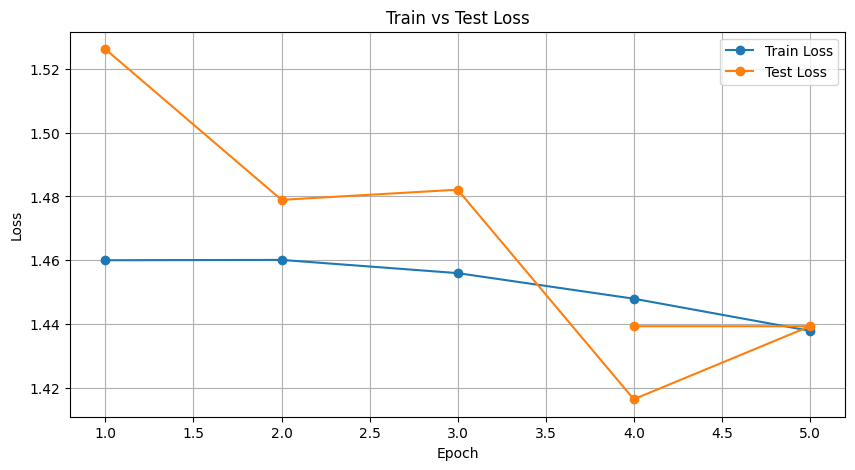

In [225]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(epoch_count[:len(train_loss_values)],
     train_loss_values,
     marker='o',
     label="Train Loss")

plt.plot(epoch_count,
         test_loss_values,
         marker='o',
         label="Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Train vs Test Loss")

plt.legend()

plt.grid(True)

plt.show()

## Create Results Table

In [218]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,model_name,train_loss,test_loss,test_accuracy
0,baseline,1.408391,1.396758,50.78
1,normalization,1.478834,1.474428,47.17


# compare

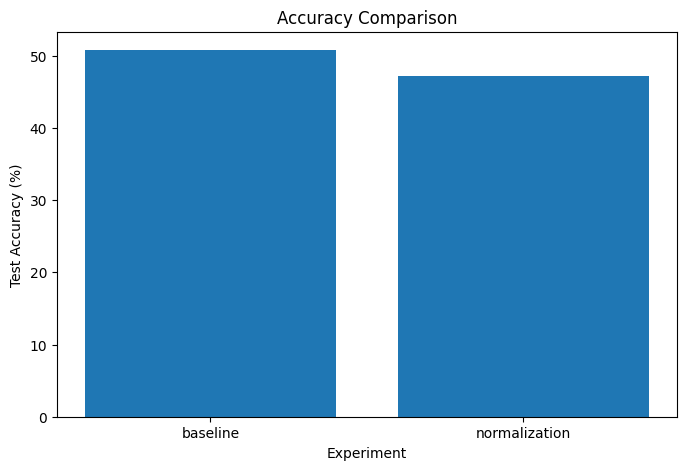

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["model_name"],
        results_df["test_accuracy"])

plt.xlabel("Experiment")

plt.ylabel("Test Accuracy (%)")

plt.title("Accuracy Comparison")

plt.show()

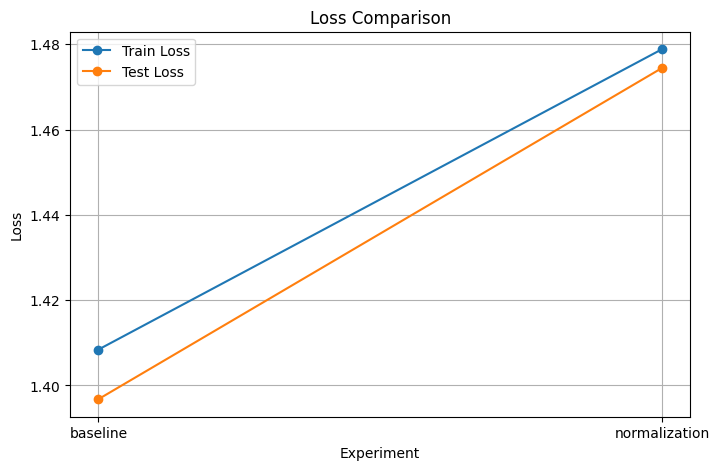

In [227]:
plt.figure(figsize=(8,5))

x = range(len(results_df))

plt.plot(x,
         results_df["train_loss"],
         marker='o',
         label="Train Loss")

plt.plot(x,
         results_df["test_loss"],
         marker='o',
         label="Test Loss")

plt.xticks(x,
           results_df["model_name"])

plt.xlabel("Experiment")

plt.ylabel("Loss")

plt.title("Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

# Visualize Predictions

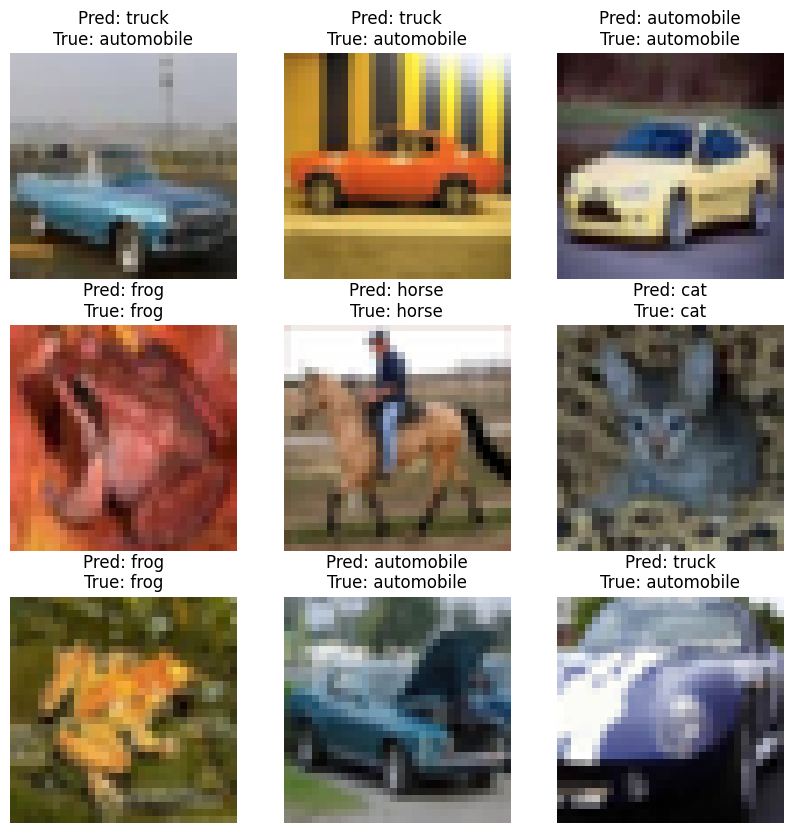

In [184]:
import random

model.eval()

with torch.inference_mode():

    fig, axes = plt.subplots(3,3, figsize=(10,10))

    for ax in axes.flat:

        idx = random.randint(0, len(test_data)-1)

        image, label = test_data[idx]

        pred = model(image.unsqueeze(0).to(device))

        pred_label = pred.argmax(dim=1).item()

        ax.imshow(image.permute(1,2,0))

        ax.set_title(
            f"Pred: {test_data.classes[pred_label]}\nTrue: {test_data.classes[label]}"
        )

        ax.axis(False)

plt.show()